In [ ]:
# 환경 설정 및 필수 패키지 설치
!pip install -q xgboost shap imbalanced-learn hyperopt

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, recall_score, f1_score, roc_auc_score
from imblearn.combine import SMOTEENN
from xgboost import XGBClassifier
import shap

import warnings
warnings.filterwarnings('ignore')

print(" 라이브러리 로드 완료!")

 라이브러리 로드 완료!


SECOM 데이터 로드 중...
원본 데이터 크기: (1567, 590), 불량률: 6.64%


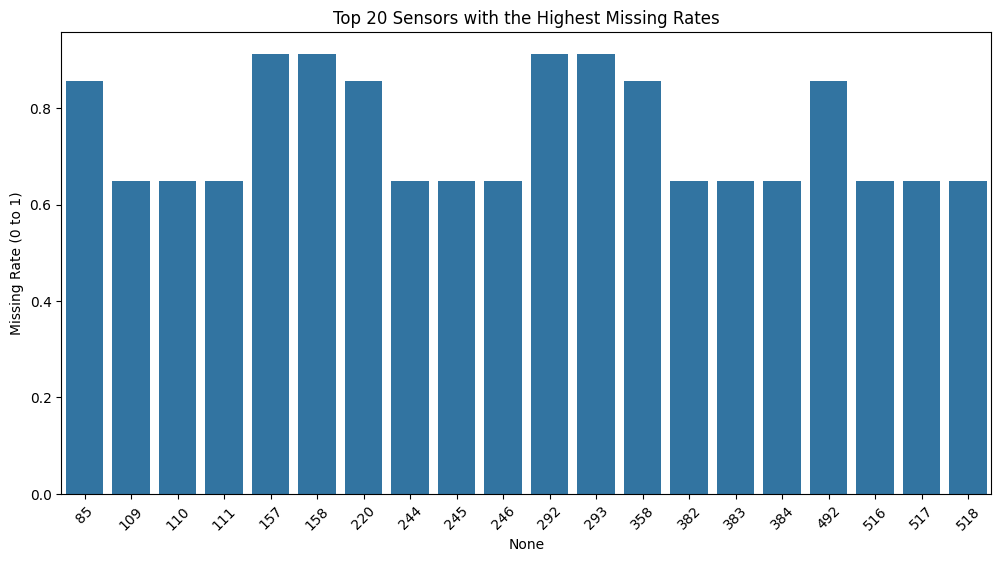

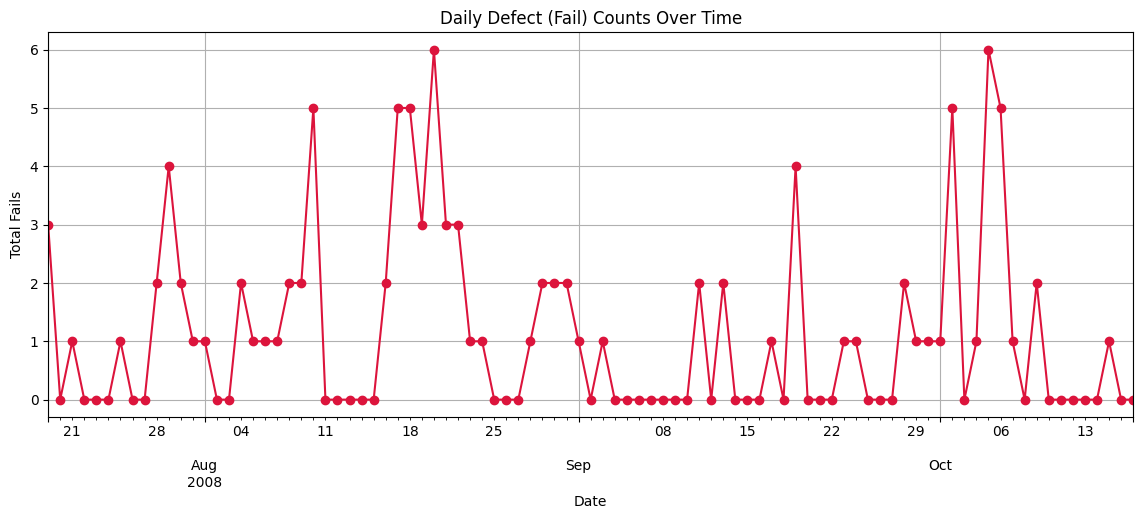

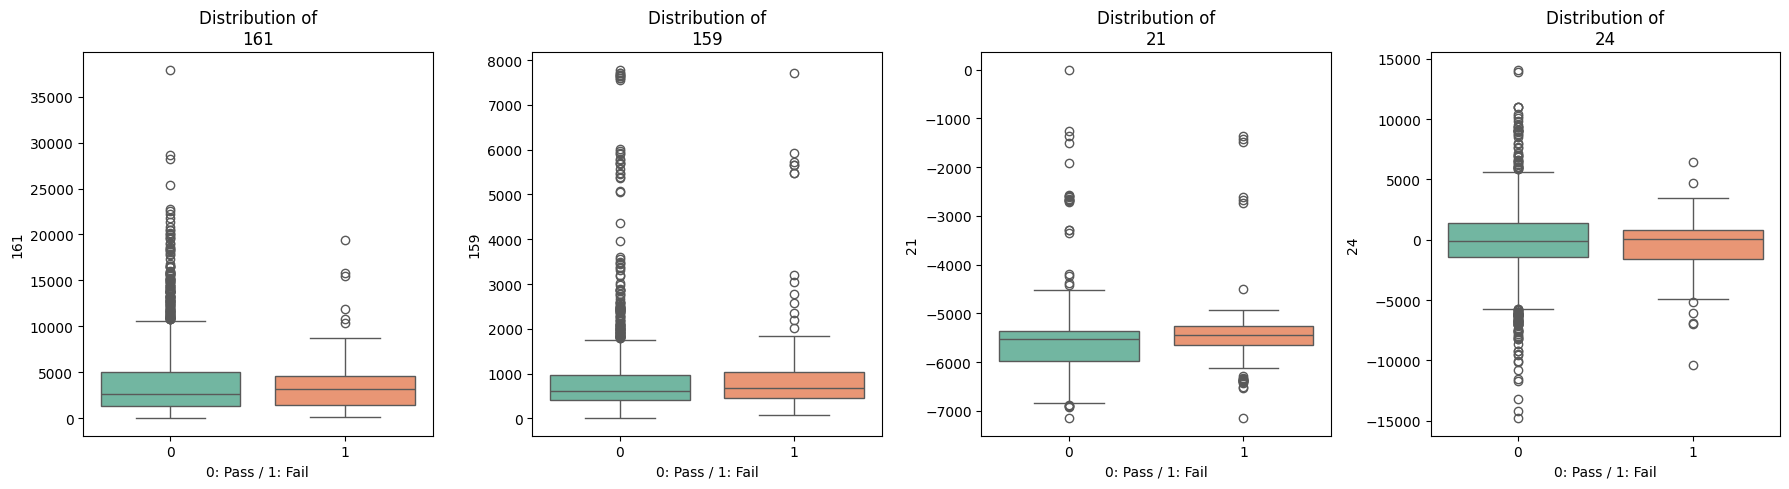

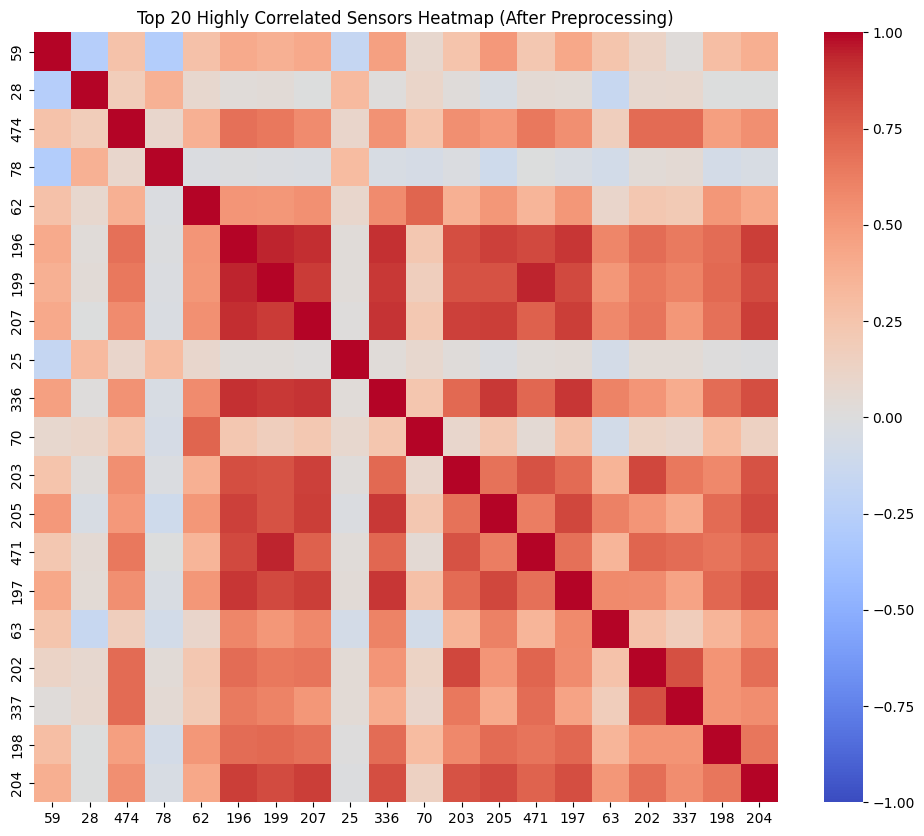

전처리 완료 후 데이터 크기: (1567, 284)


In [ ]:
# 데이터 로드 및 전처리 (EDA & Feature Selection)

# UCI 저장소에서 SECOM 데이터 직접 로드
print("SECOM 데이터 로드 중...")
url_x = "https://archive.ics.uci.edu/ml/machine-learning-databases/secom/secom.data"
url_y = "https://archive.ics.uci.edu/ml/machine-learning-databases/secom/secom_labels.data"

X = pd.read_csv(url_x, sep=" ", header=None)
y = pd.read_csv(url_y, sep=" ", header=None)[0]
y = y.apply(lambda x: 1 if x == 1 else 0) # 1: Fail(불량), 0: Pass(정상)

# 1. 데이터 분석
# 1-1. 결측률이 가장 높은 센서들
print(f"원본 데이터 크기: {X.shape}, 불량률: {y.mean()*100:.2f}%")
# 결측률 계산 후 내림차순 정렬
missing_rates = X.isnull().mean().sort_values(ascending=False)

# 결측률이 가장 높은 상위 20개 센서 시각화
plt.figure(figsize=(12, 6))
sns.barplot(x=missing_rates.head(20).index, y=missing_rates.head(20).values)
plt.title("Top 20 Sensors with the Highest Missing Rates")
plt.xticks(rotation=45)
plt.ylabel("Missing Rate (0 to 1)")
plt.show()

# 1-2.특정 기간에 불량이 집중되는가? / 월별 불량 발생 추이가 일정하지 않음 → 공정 조건 변화 시사
# 라벨 파일에서 시간 데이터(2번째 열) 가져와서 datetime 형식으로 변환
time_data = pd.read_csv(url_y, sep=" ", header=None)[1]
time_data = pd.to_datetime(time_data, format="%d/%m/%Y %H:%M:%S", errors='coerce')

# 시간과 불량(y) 데이터를 합침
df_time = pd.DataFrame({'Time': time_data, 'Fail': y})
df_time.set_index('Time', inplace=True)

# 일별(Daily) 불량 발생 건수 집계
daily_fails = df_time['Fail'].resample('D').sum()

# 시계열 그래프 시각화
plt.figure(figsize=(14, 5))
daily_fails.plot(kind='line', marker='o', color='crimson')
plt.title("Daily Defect (Fail) Counts Over Time")
plt.ylabel("Total Fails")
plt.xlabel("Date")
plt.grid(True)
plt.show()

# 1.3. 어떤 변수에서 정상/불량 분포 차이가 가장 큰가
# 정상과 불량 간의 평균 차이가 가장 큰 변수들을 찾아 박스플롯(Boxplot)으로 비교
# 전처리 완료된 X와 y 결합
df_eda = X.copy()
df_eda['Target'] = y.values

# 정상(0)과 불량(1) 그룹의 센서별 평균값을 구하고, 그 차이(절대값)가 가장 큰 4개 찾기
mean_diff = df_eda.groupby('Target').mean().diff().iloc[1].abs().sort_values(ascending=False)
top_4_features = mean_diff.head(4).index

# 상위 4개 변수의 정상/불량 분포 시각화
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for i, col in enumerate(top_4_features):
    sns.boxplot(x='Target', y=col, data=df_eda, ax=axes[i], palette='Set2')
    axes[i].set_title(f"Distribution of\n{col}")
    axes[i].set_xlabel("0: Pass / 1: Fail")

plt.tight_layout()
plt.show()

# 2. 전처리 1단계: 결측치 90% 이상인 센서 변수 제거
missing_ratio = X.isnull().mean()
cols_to_keep = missing_ratio[missing_ratio < 0.9].index
X = X[cols_to_keep]

# 3. 전처리 2단계: 분산이 0인 상수 피처 제거
X = X.loc[:, X.nunique() > 1] # 고유값(Unique value)의 개수를 세어주는 함수 (모두 같은 값이면 1, 1보다 큰 것만 사용)

# 4. 전처리 3단계: 중앙값(Median)으로 결측치 대체
X = X.fillna(X.median())

# 5. 전처리 4단계: 상관계수 0.95 이상인 중복 변수 제거
corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)) #Triangle Upper
to_drop = [column for column in upper.columns if any(upper[column] >= 0.95)]
X = X.drop(columns=to_drop)

#6. 상관계수가 높은 상위 20개 변수만 추려서 히트맵
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 전처리와 컬럼명 변경이 모두 끝난 현재 X를 기준으로 상관계수를 다시 계산
final_corr_matrix = X.corr().abs()

# 2. 평균 상관계수가 가장 높은 상위 20개 컬럼 추출
top_corr_cols = final_corr_matrix.mean().nlargest(20).index
top_corr_matrix_plot = X[top_corr_cols].corr()

# 3. 히트맵 그리기
plt.figure(figsize=(12, 10))
sns.heatmap(top_corr_matrix_plot,
            annot=False,
            cmap='coolwarm',
            vmin=-1, vmax=1)
plt.title("Top 20 Highly Correlated Sensors Heatmap (After Preprocessing)")
plt.show()

# 컬럼명 문자열로 변환 (XGBoost 호환성)
X.columns = [f"Sensor_{c}" for c in X.columns]

print(f"전처리 완료 후 데이터 크기: {X.shape}")

RandomForest 임시 모델 학습 및 특징 중요도 추출 중...
특징 중요도 기반 최종 차원 축소 완료: 284개 -> 50개


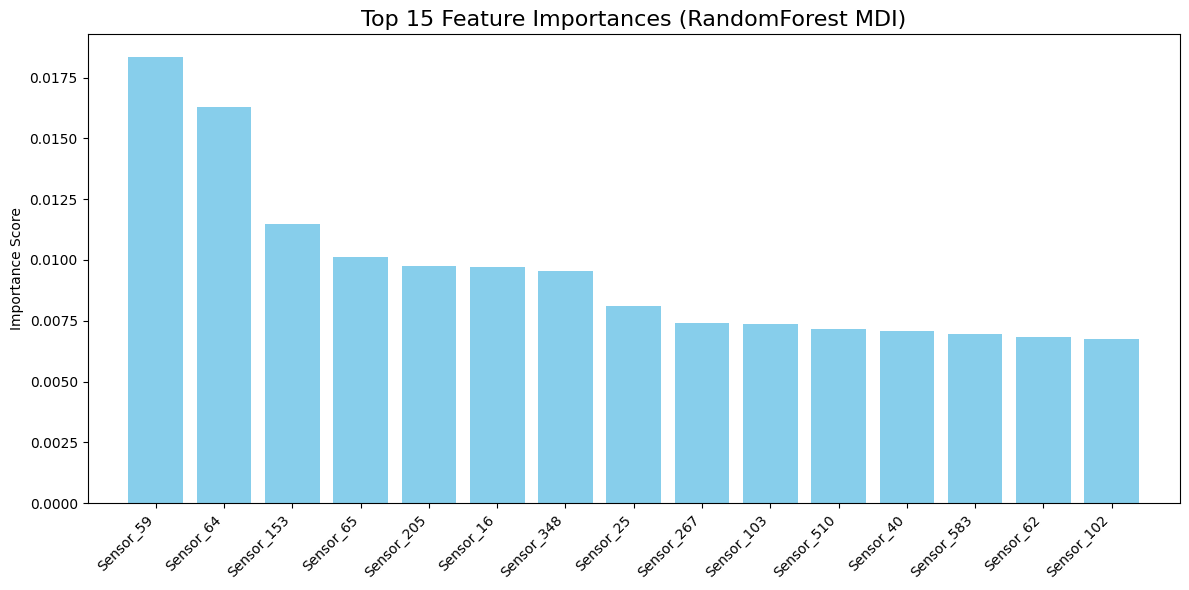

In [ ]:
# RandomForest 특징 중요도(MDI)를 활용한 피처 선택 (Top 50)
from sklearn.ensemble import RandomForestClassifier

print("RandomForest 임시 모델 학습 및 특징 중요도 추출 중...")

# 피처 선택을 위한 임시 RandomForest 모델 학습 (결측치 처리가 완료된 X, y 사용)
rf_selector = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_selector.fit(X, y)

# 특징 중요도(Mean Decrease in Impurity) 추출
importances = rf_selector.feature_importances_

# 중요도 순으로 내림차순 정렬하여 상위 50개 인덱스 추출
indices = np.argsort(importances)[::-1]
top_50_indices = indices[:50]
top_50_features = X.columns[top_50_indices]

# 원본 데이터셋을 상위 50개 변수로 최종 압축
X_selected = X[top_50_features]

print(f"특징 중요도 기반 최종 차원 축소 완료: {X.shape[1]}개 -> {X_selected.shape[1]}개")

# 시각화 (어떤 변수가 가장 중요한지 상위 15개 피처 확인)
plt.figure(figsize=(12, 6))
plt.title("Top 15 Feature Importances (RandomForest MDI)", fontsize=16)
plt.bar(range(15), importances[indices[:15]], align="center", color='skyblue')
plt.xticks(range(15), X.columns[indices[:15]], rotation=45, ha='right')
plt.xlim([-1, 15])
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()

In [ ]:
# 데이터 분할 및 SMOTEENN을 통한 불균형 해결

# Train / Test 분할 (계층화 추출로 불량 비율 유지)
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
# 압축된 X_selected를 사용하여 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, stratify=y, random_state=42)

print(f"SMOTE 적용 전 훈련 세트 불량 개수: {sum(y_train == 1)} / 정상 개수: {sum(y_train == 0)}")

# SMOTEENN 적용 (학습 데이터에만 적용)
# ENN(Edited Nearest Neighbours)/생성된 데이터를 포함해 전체 데이터 확인
# 특정 '정상' 데이터 주변을 탐색했을 때, 이웃한 데이터 중 다수가 '불량' 데이터라면?
# ENN은 이 '정상' 데이터를 "분류 경계를 모호하게 만드는 헷갈리는 데이터(노이즈)"로 판단하고 과감하게 삭제
smote_enn = SMOTEENN(random_state=42)
X_train_res, y_train_res = smote_enn.fit_resample(X_train, y_train)

print(f" SMOTEENN 적용 후 훈련 세트 불량 개수: {sum(y_train_res == 1)} / 정상 개수: {sum(y_train_res == 0)}")

SMOTE 적용 전 훈련 세트 불량 개수: 83 / 정상 개수: 1170
 SMOTEENN 적용 후 훈련 세트 불량 개수: 1112 / 정상 개수: 721


In [ ]:
# RandomForest 및 XGBoost 모델 학습 및 평가

def evaluate_model(model, name):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    print(f"=== {name} 성능 평가 ===")
    print(f"Recall (불량 검출률): {recall_score(y_test, y_pred):.4f}")
    print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")
    print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("-" * 30)

# 1. Random Forest 학습 (Bagging 방식)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_res, y_train_res)
evaluate_model(rf_model, "RandomForest")

# 2. XGBoost 학습 (Boosting 방식 - 희소성 인지 분할 지원)
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5,
                          random_state=42, eval_metric='logloss')
xgb_model.fit(X_train_res, y_train_res)
evaluate_model(xgb_model, "XGBoost")

# XGBoost가 복잡한 비선형 관계에서 대체로 더 우수한 검출률(Recall)을 보입니다.

=== RandomForest 성능 평가 ===
Recall (불량 검출률): 0.1905
F1-Score: 0.1905
ROC-AUC: 0.7850
Confusion Matrix:
 [[276  17]
 [ 17   4]]
------------------------------
=== XGBoost 성능 평가 ===
Recall (불량 검출률): 0.3333
F1-Score: 0.2745
ROC-AUC: 0.7751
Confusion Matrix:
 [[270  23]
 [ 14   7]]
------------------------------


In [ ]:
# 3x3 실험 설계: 모델 3종 x 학습 데이터 3종 성능 비교
!pip install -q lightgbm
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
import pandas as pd

# 1. 3가지 학습 데이터셋 준비
print(" 학습 데이터셋 3종(Original, SMOTE, SMOTEENN) 준비 중...")
# (1) 원본 데이터
X_train_orig, y_train_orig = X_train, y_train

# (2) SMOTE 적용 데이터
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# (3) SMOTEENN 적용 데이터
smote_enn = SMOTEENN(random_state=42)
X_train_sme, y_train_sme = smote_enn.fit_resample(X_train, y_train)

datasets = {
    "Original": (X_train_orig, y_train_orig),
    "SMOTE": (X_train_sm, y_train_sm),
    "SMOTEENN": (X_train_sme, y_train_sme)
}

# 2. 3가지 모델 준비
models = {
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42, eval_metric='logloss'),
    "LightGBM": LGBMClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42, verbose=-1)
}

# 3. 3x3 교차 실험 및 결과 저장
results = []

print(" 9가지 조합 모델 학습 및 평가 시작...\n")
for data_name, (X_tr, y_tr) in datasets.items():
    for model_name, model in models.items():
        # 모델 학습
        model.fit(X_tr, y_tr)

        # 예측 및 확률 계산
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]

        # 평가 지표 산출
        acc = accuracy_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_proba)

        results.append({
            "Dataset": data_name,
            "Model": model_name,
            "Accuracy": acc,
            "Recall": recall,
            "Precision": precision,
            "F1-Score": f1,
            "ROC-AUC": auc
        })

# 4. 결과 출력
results_df = pd.DataFrame(results)
# 현장에서 가장 중요한 F1-Score를 기준으로 내림차순 정렬
results_df = results_df.sort_values(by="F1-Score", ascending=False).reset_index(drop=True)

display(results_df.style.background_gradient(cmap='Blues', subset=['Recall', 'F1-Score', 'ROC-AUC']))
print("\n 3x3 실험 완료! F1-Score 기준 최적의 조합을 확인")

 학습 데이터셋 3종(Original, SMOTE, SMOTEENN) 준비 중...
 9가지 조합 모델 학습 및 평가 시작...



,Dataset,Model,Accuracy,Recall,Precision,F1-Score,ROC-AUC
0,SMOTEENN,LightGBM,0.878981,0.380952,0.242424,0.296296,0.795222
1,SMOTEENN,XGBoost,0.882166,0.333333,0.233333,0.274510,0.775069
2,Original,XGBoost,0.942675,0.142857,1.000000,0.250000,0.743702
3,SMOTEENN,RandomForest,0.891720,0.190476,0.190476,0.190476,0.784983
4,SMOTE,XGBoost,0.914013,0.142857,0.250000,0.181818,0.784820
5,SMOTE,LightGBM,0.914013,0.142857,0.250000,0.181818,0.748090
6,Original,LightGBM,0.936306,0.095238,0.666667,0.166667,0.769706
7,SMOTE,RandomForest,0.920382,0.047619,0.166667,0.074074,0.810174
8,Original,RandomForest,0.933121,0.000000,0.000000,0.000000,0.805623



 3x3 실험 완료! F1-Score 기준 최적의 조합을 확인


[SHAP Summary Plot] 전체 변수 중요도 및 방향성


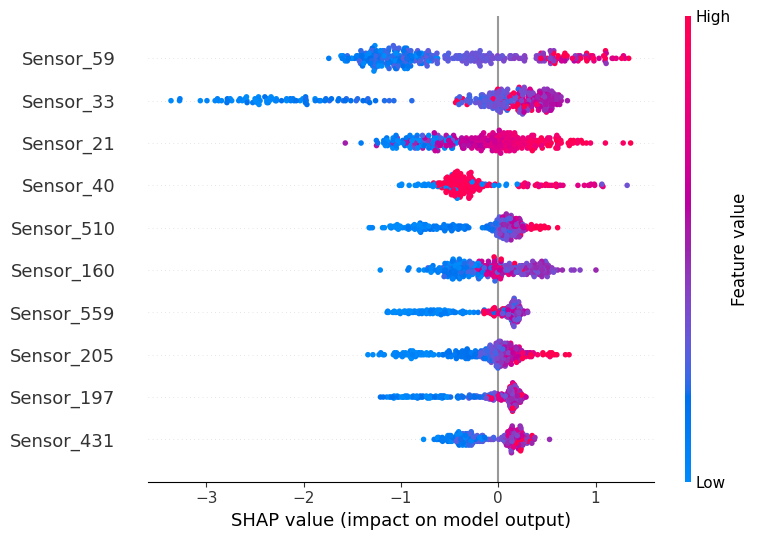

SHAP 불량 판정 원인 비교 분석 시작

[Case 1: 정답!] 웨이퍼 인덱스 56
실제: 불량 / 모델 예측: 불량 (f(x)가 양수(+)로 크게 나옴)


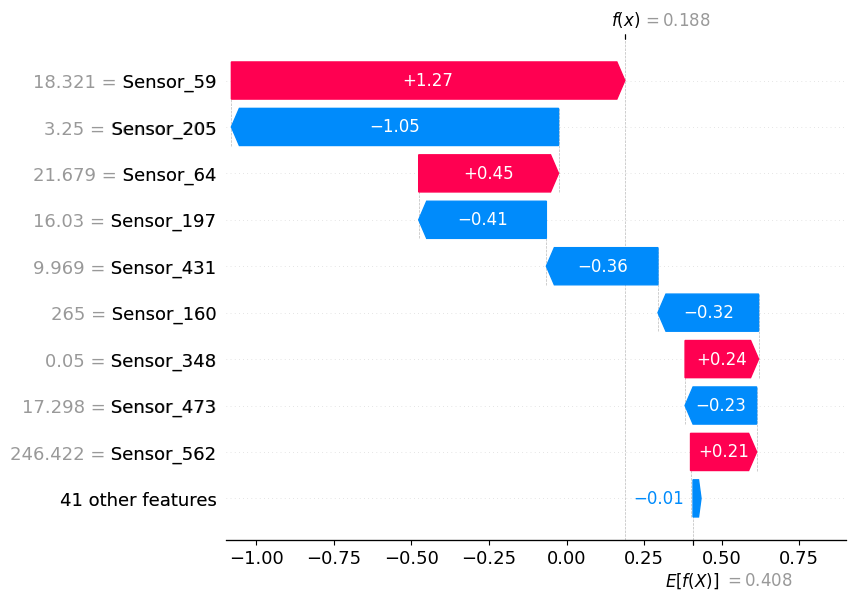


[Case 2: 오판] 웨이퍼 인덱스 37
실제: 불량 / 모델 예측: 정상 (f(x)가 음수(-)로 나온 케이스(FN))


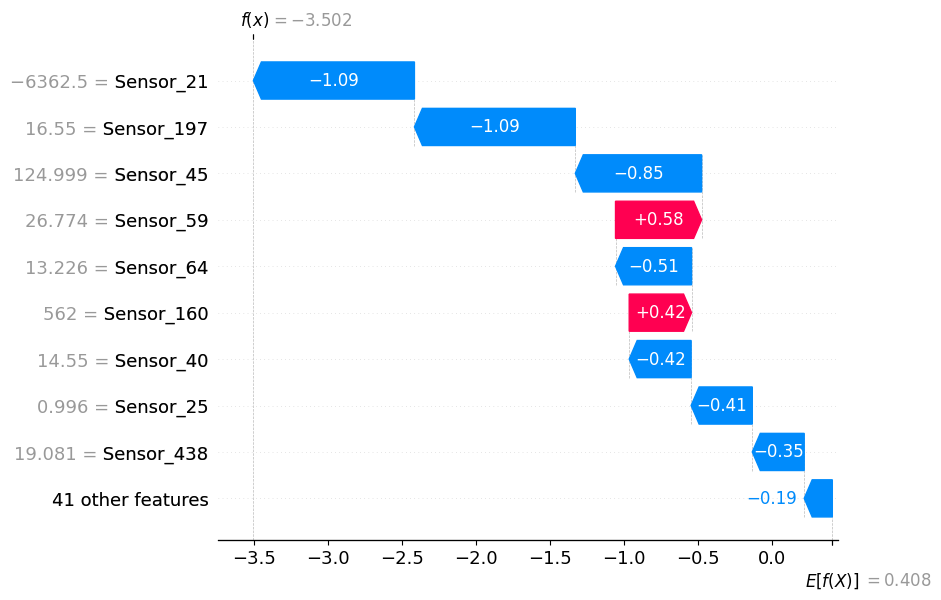


전체 테스트 데이터 기준 가장 영향력이 큰 센서: Sensor_59
가장 중요한 원인 변수로 식별된 센서: Sensor_59


In [ ]:
# SHAP 불량 원인 규명 및 시각화

# SHAP Explainer 생성 (XGBoost 모델 기준)
explainer = shap.Explainer(xgb_model)
shap_values = explainer(X_test)

# 1. Summary Plot: 전체 테스트 데이터에서 어떤 변수가 불량(Class 1)에 기여하는가?
print("[SHAP Summary Plot] 전체 변수 중요도 및 방향성")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, max_display=10)
plt.show()

# # 2. Waterfall Plot: 특정 웨이퍼 1개가 '왜' 불량으로 판정되었는가? (Local Explanation)
# # 실제 불량(Fail)인 샘플 중 하나를 선택하여 추적
# fail_indices = np.where(y_test == 1)[0]
# sample_idx = fail_indices[0]

# print(f"\n[SHAP Waterfall Plot] 웨이퍼 인덱스 {sample_idx}의 불량 판정 원인 분해")
# shap.plots.waterfall(shap_values[sample_idx], max_display=10)

# 1. 모델의 예측값 계산
y_pred = xgb_model.predict(X_test)

# y_test가 pandas Series일 경우를 대비해 numpy 배열로 변환 (인덱싱 오류 방지)
y_test_np = np.array(y_test)

# 2. 인덱스 조건별 추출
# A. True Positive: 실제 불량(1) & 모델 예측도 불량(1) -> '진짜 불량 판정' 샘플
tp_indices = np.where((y_test_np == 1) & (y_pred == 1))[0]

# B. False Negative: 실제 불량(1) & 모델 예측은 정상(0) -> '오판' 샘플
fn_indices = np.where((y_test_np == 1) & (y_pred == 0))[0]

# 3. Waterfall Plot 비교 출력
print("SHAP 불량 판정 원인 비교 분석 시작\n" + "="*50)

# --- A. 진짜 불량(TP) 샘플 분석 ---
if len(tp_indices) > 0:
    tp_idx = tp_indices[0] # 첫 번째 TP 샘플
    print(f"\n[Case 1: 정답!] 웨이퍼 인덱스 {tp_idx}")
    print("실제: 불량 / 모델 예측: 불량 (f(x)가 양수(+)로 크게 나옴)")

    plt.figure(figsize=(8, 5))
    shap.plots.waterfall(shap_values[tp_idx], max_display=10)
    plt.show()
else:
    print("\n[Case 1] 모델이 불량을 정확히 맞춘 샘플이 하나도 없음 (Recall = 0).")

# --- B. 오판한 불량(FN) 샘플 분석 ---
if len(fn_indices) > 0:
    fn_idx = fn_indices[0] # FN 중 하나.
    print(f"\n[Case 2: 오판] 웨이퍼 인덱스 {fn_idx}")
    print("실제: 불량 / 모델 예측: 정상 (f(x)가 음수(-)로 나온 케이스(FN))")

    plt.figure(figsize=(8, 5))
    shap.plots.waterfall(shap_values[fn_idx], max_display=10)
    plt.show()
else:
    print("\n[Case 2] 모델이 불량을 정상으로 오판한 샘플 없음.")

# 4. 가장 중요한 센서 추출 (전체 기준)
top_feature = X_test.columns[np.argsort(np.abs(shap_values.values).mean(axis=0))[-1]]
print(f"\n전체 테스트 데이터 기준 가장 영향력이 큰 센서: {top_feature}")

# 가장 영향력이 큰 센서 변수를 추출
top_feature = X_test.columns[np.argsort(np.abs(shap_values.values).mean(axis=0))[-1]]
print(f"가장 중요한 원인 변수로 식별된 센서: {top_feature}")

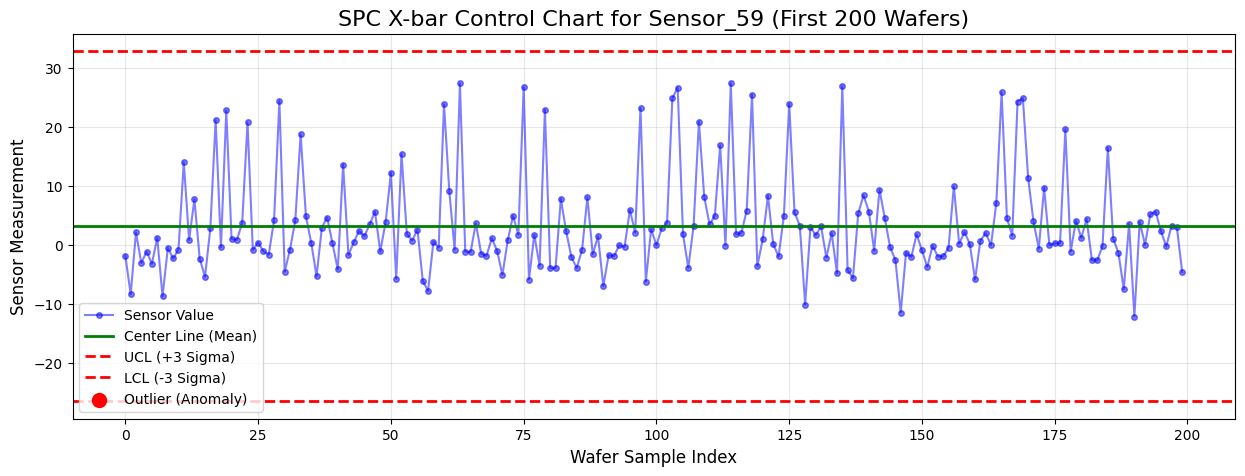

최적화 가이드: Sensor_59 센서의 값이 LCL(-26.48)과 UCL(32.77) 사이를 유지하도록 공정 파라미터를 제어해야 함.


In [ ]:
# 공정 최적화 및 SPC(X-bar 관리도) 시각화

# SHAP에서 찾아낸 가장 중요한 변수에 대해 X-bar 관리도 작성
# (실제 현장에서는 베이지안 최적화로 구한 최적 설정값을 중심선으로 활용할 수도 있음)

feature_data = X_train[top_feature]
mean_val = feature_data.mean()
std_val = feature_data.std()

# 3-Sigma(표준편차) 규칙 기반의 관리 상하한선 (UCL, LCL)
ucl = mean_val + 3 * std_val
lcl = mean_val - 3 * std_val

plt.figure(figsize=(15, 5))
plt.plot(feature_data.values[:200], marker='o', color='b', alpha=0.5, markersize=4, label='Sensor Value')
plt.axhline(mean_val, color='g', linestyle='-', linewidth=2, label='Center Line (Mean)')
plt.axhline(ucl, color='r', linestyle='--', linewidth=2, label='UCL (+3 Sigma)')
plt.axhline(lcl, color='r', linestyle='--', linewidth=2, label='LCL (-3 Sigma)')

# 관리 한계를 벗어난 이상치(Outlier) 붉은색 표시
outliers = np.where((feature_data.values[:200] > ucl) | (feature_data.values[:200] < lcl))[0]
plt.scatter(outliers, feature_data.values[outliers], color='red', s=100, zorder=5, label='Outlier (Anomaly)')

plt.title(f"SPC X-bar Control Chart for {top_feature} (First 200 Wafers)", fontsize=16)
plt.xlabel("Wafer Sample Index", fontsize=12)
plt.ylabel("Sensor Measurement", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"최적화 가이드: {top_feature} 센서의 값이 LCL({lcl:.2f})과 UCL({ucl:.2f}) 사이를 유지하도록 공정 파라미터를 제어해야 함.")

[Step 3] Dependence Plot: TOP 3 변수의 임계값 분석


<Figure size 800x500 with 0 Axes>

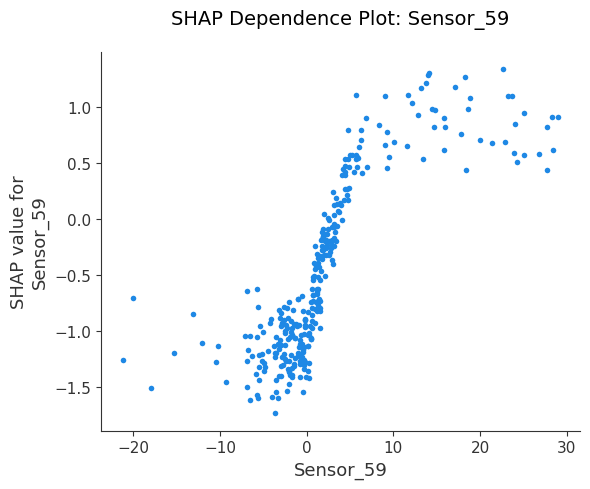

<Figure size 800x500 with 0 Axes>

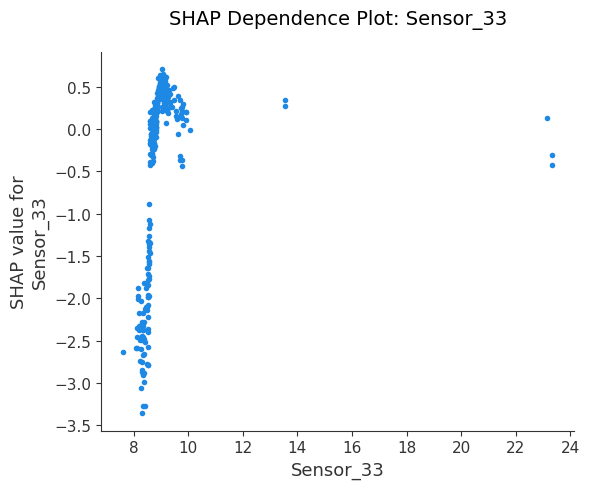

<Figure size 800x500 with 0 Axes>

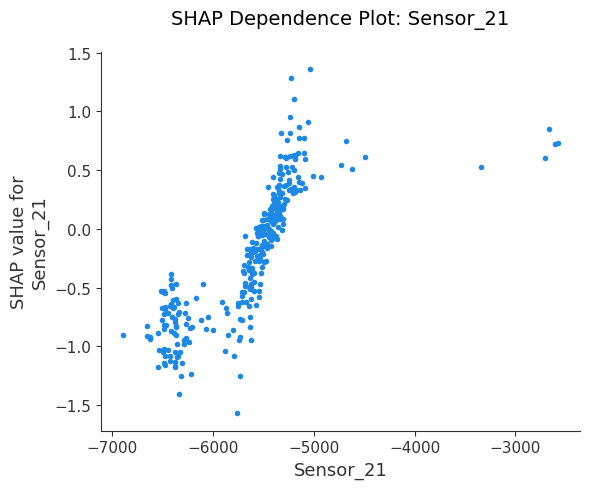


💡 [Step 4] 공정 개선 방향 도출 (TOP 3 핵심 변수)
[1위 핵심 변수] Sensor_59 (상관계수: 0.81)
 제안: 향후 공정 레시피에서 이 센서의 값을 **낮추는(Decrease)** 방향으로 관리해야 함.
 사유: 센서 측정값이 커질수록 불량 확률(SHAP Value)이 급격히 높아지는 양의 상관관계.

[2위 핵심 변수] Sensor_33 (상관계수: 0.21)
 제안: 향후 공정 레시피에서 이 센서의 값을 **낮추는(Decrease)** 방향으로 관리해야 함.
 사유: 센서 측정값이 커질수록 불량 확률(SHAP Value)이 급격히 높아지는 양의 상관관계.

[3위 핵심 변수] Sensor_21 (상관계수: 0.77)
 제안: 향후 공정 레시피에서 이 센서의 값을 **낮추는(Decrease)** 방향으로 관리해야 함.
 사유: 센서 측정값이 커질수록 불량 확률(SHAP Value)이 급격히 높아지는 양의 상관관계.



In [ ]:
import shap
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr

# ---------------------------------------------------------
# ③ Dependence Plot: TOP 3 변수의 임계값 분석
# ---------------------------------------------------------
print("[Step 3] Dependence Plot: TOP 3 변수의 임계값 분석\n" + "="*50)

# 전체 SHAP 값의 절대값 평균을 기준으로 영향력이 가장 큰 TOP 3 변수 추출
mean_shap_abs = np.abs(shap_values.values).mean(axis=0)
top3_indices = np.argsort(mean_shap_abs)[-3:][::-1] # 1위 -> 2위 -> 3위 순서로 정렬
top3_features = X_test.columns[top3_indices]

# TOP 3 변수에 대해 각각 Dependence Plot 시각화
for feature in top3_features:
    plt.figure(figsize=(8, 5))
    # interaction_index=None으로 설정하여 다른 변수와의 교호작용 없이 순수 해당 변수 패턴만 파악
    shap.dependence_plot(feature, shap_values.values, X_test, interaction_index=None, show=False)
    plt.title(f"SHAP Dependence Plot: {feature}", pad=20, fontsize=14)
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------
# ④ 공정 개선 방향 도출: 어떤 변수를 어느 방향으로 조정할지
# ---------------------------------------------------------
print("\n💡 [Step 4] 공정 개선 방향 도출 (TOP 3 핵심 변수)\n" + "="*50)

for i, feature in enumerate(top3_features, 1):
    # 해당 변수의 실제 측정값과 SHAP 값(불량 기여도) 추출
    feat_idx = X_test.columns.get_loc(feature)
    feat_vals = X_test[feature].values
    shap_vals = shap_values.values[:, feat_idx]

    # 두 값 간의 피어슨 상관계수를 계산하여 비례/반비례(양/음의 상관관계) 파악
    corr, _ = pearsonr(feat_vals, shap_vals)

    # 상관계수에 따른 자동 액션 플랜 도출 로직
    if corr > 0.1:
        direction = "낮추는(Decrease)"
        reason = "센서 측정값이 커질수록 불량 확률(SHAP Value)이 급격히 높아지는 양의 상관관계"
    elif corr < -0.1:
        direction = "높이는(Increase)"
        reason = "센서 측정값이 작아질수록 불량 확률(SHAP Value)이 급격히 높아지는 음의 상관관계"
    else:
        direction = "현재 수준 중앙값 유지 및 변동폭(산포) 최소화"
        reason = "단순한 증감보다는 특정 구간(Threshold)을 벗어났을 때 불량 확률이 변하는 비선형적 패턴"

    print(f"[{i}위 핵심 변수] {feature} (상관계수: {corr:.2f})")
    print(f" 제안: 향후 공정 레시피에서 이 센서의 값을 **{direction}** 방향으로 관리해야 함.")
    print(f" 사유: {reason}.\n")

[Sensor_59] 임계값(Threshold) 분석 결과
결론: Sensor_59의 측정값이 **1.95 이상**으로 올라가면 불량 위험(SHAP > 0)이 급증


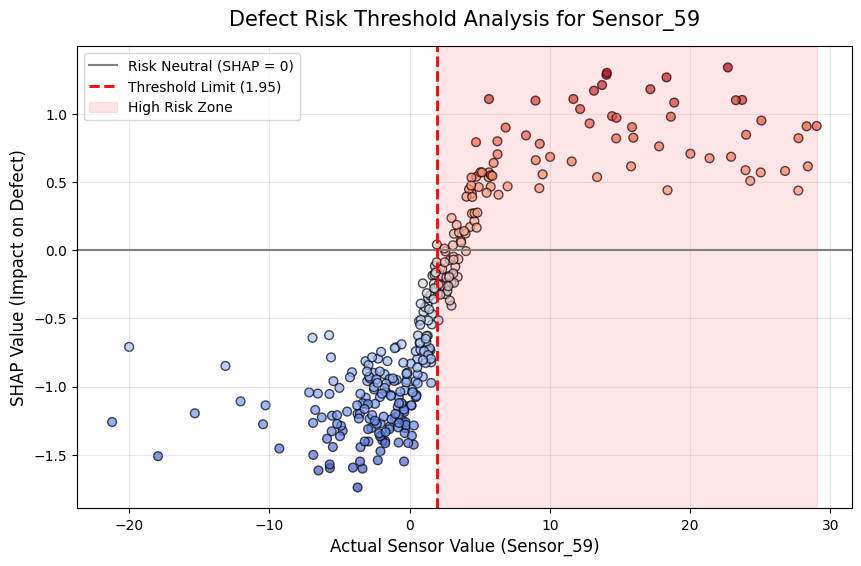

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 분석할 핵심 변수 지정 (앞서 구한 top_feature 활용)
feature_name = top_feature # 예: 'Sensor_59'
feature_idx = X_test.columns.get_loc(feature_name)

# 해당 변수의 실제 센서 측정값과 SHAP 값 추출
feat_vals = X_test[feature_name].values
shap_vals = shap_values.values[:, feature_idx]

# SHAP 값이 0보다 큰(불량에 기여하는) 데이터들의 실제 센서 값들만 필터링
risky_feat_vals = feat_vals[shap_vals > 0]

# 변수와 SHAP 값 간의 상관계수로 방향성(우상향/우하향) 파악
correlation = np.corrcoef(feat_vals, shap_vals)[0, 1]

plt.figure(figsize=(10, 6))
# 산점도 그리기 (SHAP 값이 높을수록 붉은색)
plt.scatter(feat_vals, shap_vals, alpha=0.7, c=shap_vals, cmap='coolwarm', edgecolor='k', s=40)
plt.axhline(0, color='gray', linestyle='-', linewidth=1.5, label='Risk Neutral (SHAP = 0)')

print(f"[{feature_name}] 임계값(Threshold) 분석 결과\n" + "="*50)

if len(risky_feat_vals) == 0:
    print("이 변수로는 불량 위험이 증가하는 뚜렷한 구간을 찾을 수 없음.")
else:
    if correlation > 0:
        # 양의 상관관계: 값이 커질수록 위험하므로, 위험 구간의 '최솟값'이 임계값이 됨
        threshold = np.min(risky_feat_vals)
        print(f"결론: {feature_name}의 측정값이 **{threshold:.2f} 이상**으로 올라가면 불량 위험(SHAP > 0)이 급증")

        plt.axvline(threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold Limit ({threshold:.2f})')
        # 위험 구간 붉은색 배경 칠하기
        plt.axvspan(threshold, max(feat_vals), color='red', alpha=0.1, label='High Risk Zone')

    else:
        # 음의 상관관계: 값이 작아질수록 위험하므로, 위험 구간의 '최댓값'이 임계값이 됨
        threshold = np.max(risky_feat_vals)
        print(f"결론: {feature_name}의 측정값이 **{threshold:.2f} 이하**로 떨어지면 불량 위험(SHAP > 0)이 급증")

        plt.axvline(threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold Limit ({threshold:.2f})')
        # 위험 구간 붉은색 배경 칠하기
        plt.axvspan(min(feat_vals), threshold, color='red', alpha=0.1, label='High Risk Zone')

plt.title(f"Defect Risk Threshold Analysis for {feature_name}", fontsize=15, pad=15)
plt.xlabel(f"Actual Sensor Value ({feature_name})", fontsize=12)
plt.ylabel("SHAP Value (Impact on Defect)", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()